In [1]:
import os,sys
from scipy import io
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import collections
import matplotlib
import matplotlib.patheffects as PathEffects
from mebocost import mebocost



plt.rcParams.update(plt.rcParamsDefault)
rc={"axes.labelsize": 16, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "figure.titleweight":"bold", #"font.size":14,
    "figure.figsize":(5.5,4.2), "font.weight":"regular", "legend.fontsize":10,
    'axes.labelpad':8, 'figure.dpi':300}
plt.rcParams.update(**rc)


MTpers=[30,30]
if MTpers[0]==MTpers[1]:
    MTper=MTpers[0]
else:
    MTper=str(MTpers[0]) + "_" + str(MTpers[1])
res=.1
res1=int(res*10**(len(str(res))-2))
dataType="Intestine"
sampleNames=["WT-HFD","LOF-HFD"]
sn="/combined"
for i in sampleNames:
  sn=sn+"_"+i
sn=sn+"_"+str(MTper)+"_"+str(res1)+"/"
print(sn)
mainDir = '/Users/krishangupta/Google Drive/My Drive/Desktop/Krishan_Gupta/Hong/'
dataDir = mainDir+"loomFiles/RNA_Velocity/"+dataType+sn
plotDir = mainDir+'analysis/SCA_plots/'+dataType+sn+"mobocost1/"
processedDataDir = mainDir+'analysis/processed_files/'+dataType+sn+"mobocost1/"

if not os.path.exists(plotDir):
    os.mkdir(plotDir)
    
if not os.path.exists(processedDataDir):
    os.mkdir(processedDataDir)

# path='/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/My Drive/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/mebocost/'
os.chdir(dataDir)
!pwd
dataName='WT-HFD_LOF-HFD'
dataType='ABC_'
conditionNames="conditions"
cellTypeNames=dataType+'subCellTypes'
cellTypeConditionNames=dataType+'Cond_SCT'
# cellTypes=["HC1 Alb hi","HC2 Alb hi","HC3 Alb hi","HC Hnf4a hi"]
cellTypes=['Cap LEC1','Cap LEC2','Cap LEC3',"Pre-Col LEC","Val LEC"]
# metabolites=['Uridine diphosphate glucose', 'Oleic acid', 'Palmitic acid','Sphingosine 1-phosphate']
# metabolites=['Uridine diphosphate glucose', 'Oleic acid', 'Palmitic acid',
#              'D-Glucose', 'D-Fructose', 'Cholesterol','Sphingosine 1-phosphate']
metabolites=['Uridine diphosphate glucose','Oleic acid', 'Palmitic acid','Cholesterol']
sensors=[]
ext='.pdf'

/combined_WT-HFD_LOF-HFD_30_1/
/Users/krishangupta/Library/CloudStorage/GoogleDrive-krishan.gupta@enders.tch.harvard.edu/My Drive/Desktop/Krishan_Gupta/Hong/loomFiles/RNA_Velocity/Intestine/combined_WT-HFD_LOF-HFD_30_1


Warning (xlmhg): Failed to import "mhg_cython" C extension.
Warning (xlmhg): Failed to import the "mhg_cython" C extension.Falling back to the pure Python implementation, which is very slow.


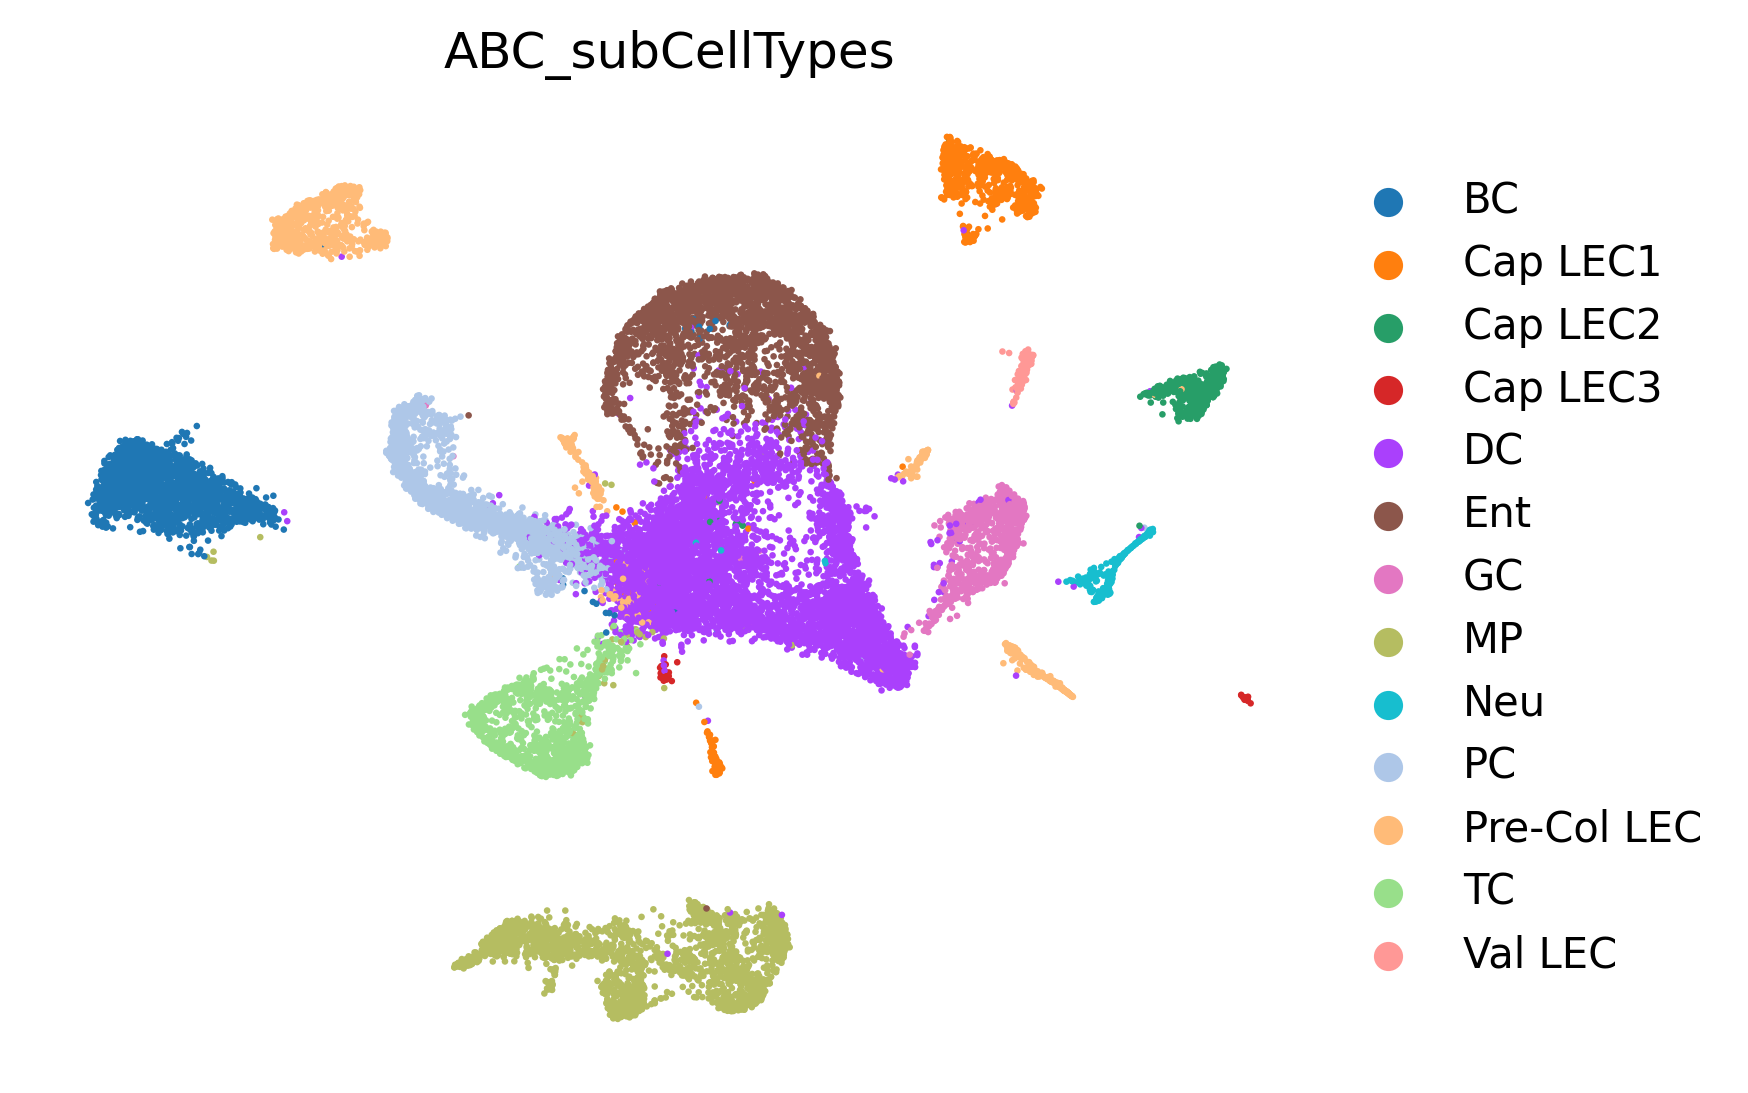

In [2]:
# load sparse matrix:
X = io.mmread(dataDir+"countsF.mtx")

# create anndata object
adata = anndata.AnnData(
    X=X.transpose().tocsr()
)

# load cell metadata:
cell_meta = pd.read_csv(dataDir+"metadataF.csv")
cell_meta.index=cell_meta.loc[:,'Unnamed: 0']
del cell_meta['Unnamed: 0']
cell_meta

# load gene names:
with open(dataDir+"gene_namesF.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = [bc[0:len(bc)-4] + '_' + cond for bc,cond in zip(adata.obs['barcode'].tolist(),adata.obs['conditions'].tolist())]
adata.var.index = gene_names

"""# load dimensional reduction:
pca = pd.read_csv(dataDir+dataType+"pca.csv")
pca.index=pca.loc[:,'Unnamed: 0']
del pca['Unnamed: 0']
pca
adata.obsm['X_pca'] = pca.to_numpy()"""

# set pca and umap
adata.obsm['X_pca'] = np.vstack((adata.obs[dataType+'PCA_1'].to_numpy(), adata.obs[dataType+'PCA_2'].to_numpy())).T
adata.obsm['X_umap'] = np.vstack((adata.obs[dataType+'UMAP_1'].to_numpy(), adata.obs[dataType+'UMAP_2'].to_numpy())).T
adata.obsm['X_tsne'] = np.vstack((adata.obs[dataType+'TSNE_1'].to_numpy(), adata.obs[dataType+'TSNE_2'].to_numpy())).T

# plot a UMAP colored by sampleID to test:
sc.pl.umap(adata, color=[cellTypeNames],size=10, frameon=False, save=dataType+cellTypeNames)

# save dataset as anndata format
adata.write(processedDataDir+'my_data.h5ad')
adata = sc.read_h5ad(processedDataDir+'my_data.h5ad')
del adata

## 1. Read scRNA-seq expression data

In [3]:
"""adata1 = sc.read_h5ad("/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/aorta_ds_wd_16weeks.h5ad")
metadata = pd.read_csv("/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/My Drive/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/aorta_ds_wd_16weeks_metadata.txt",sep="\t")
adata1.obs['cellgroup'] = metadata['cellgroup'].values
adata1.obs['celltype'] = metadata['celltype'].values
adata1.obs"""

'adata1 = sc.read_h5ad("/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/aorta_ds_wd_16weeks.h5ad")\nmetadata = pd.read_csv("/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/My Drive/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/aorta_ds_wd_16weeks_metadata.txt",sep="\t")\nadata1.obs[\'cellgroup\'] = metadata[\'cellgroup\'].values\nadata1.obs[\'celltype\'] = metadata[\'celltype\'].values\nadata1.obs'

In [4]:
# reload dataset
adata = sc.read_h5ad(processedDataDir+'my_data.h5ad')
adata = adata[adata.obs[cellTypeNames].isin(cellTypes)]


print(adata)
print(adata.obs[cellTypeNames].value_counts().shape)
print(adata.obs[cellTypeConditionNames].value_counts().shape)
print(adata.obs[conditionNames].value_counts().shape)
adata.obs_names_make_unique()
print(adata.obs[cellTypeNames].value_counts().shape)
print(adata.obs[cellTypeConditionNames].value_counts().shape)
print(adata.obs[conditionNames].value_counts().shape)

View of AnnData object with n_obs × n_vars = 2629 × 20518
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'conditions', 'conditionsBatched', 'RNA_PCA_1', 'RNA_PCA_2', 'RNA_UMAP_1', 'RNA_UMAP_2', 'RNA_TSNE_1', 'RNA_TSNE_2', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_clusters', 'ABC_PCA_1', 'ABC_PCA_2', 'ABC_UMAP_1', 'ABC_UMAP_2', 'ABC_TSNE_1', 'ABC_TSNE_2', 'integrated_snn_res.0.1', 'ABC_clusters', 'ABC_cellTypes', 'ABC_Cond_CT', 'ABC_subCellTypes', 'ABC_Cond_SCT', 'ABC_subCellTypes1', 'ABC_Cond_SCT1', 'barcode'
    uns: 'ABC_subCellTypes_colors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
(5,)
(10,)
(2,)
(5,)
(10,)
(2,)


## 2. Infer metabolic communications

In [5]:
## initiate the mebocost object
### pass expression data by scanpy adata object
mebo_obj = mebocost.create_obj(
                        adata = adata,
                        #group_col = ['celltype'],
                        group_col = [cellTypeNames, conditionNames],
                        met_est = 'mebocost',
                        config_path = mainDir+'MEBOCOST/mebocost.conf',
                        exp_mat=None,
                        cell_ann=None,
                        species='mouse',
                        met_pred=None,
                        met_enzyme=None,
                        met_sensor=None,
                        met_ann=None,
                        scFEA_ann=None,
                        compass_met_ann=None,
                        compass_rxn_ann=None,
                        gene_network=None,
                        gmt_path=None,
                        cutoff_exp=0.1,
                        cutoff_met=0.1,
                        cutoff_prop=0.25, # default 0.25
                        sensor_type=['Receptor', 'Transporter', 'Nuclear Receptor'],
                        thread=8
                        )

## metabolic communication inference
## Note: by default, this function include estimator for metabolite abundance
commu_res = mebo_obj.infer_commu(
                                n_shuffle=1000,
                                seed=12345, 
                                Return=True, 
                                thread=None,
                                save_permuation=False,
                                min_cell_number = 5
                                )
#?mebo_obj.infer_commu
## check cutoff
print('sensor_exp cutoff: %s'%mebo_obj.cutoff_exp)
print('metabolite_presence cutoff: %s'%mebo_obj.cutoff_met)
# mebo_obj.cell_ann
commu_res.to_csv(processedDataDir+'metabolite_abudance.xls', index=None, sep='\t')
commu_res.Sender.unique()


### save 
mebocost.save_obj(obj = mebo_obj, path = processedDataDir+'_commu_0.75.pk')

[July 23, 2026 15:09:02]: We get expression data with 20518 genes and 2629 cells.
[July 23, 2026 15:09:02]: Data Preparation Done in 0.0229 seconds
[July 23, 2026 15:09:02]: Load config and read data based on given species [mouse].
[July 23, 2026 15:09:04]: Estimtate metabolite level using mebocost
[July 23, 2026 15:09:20]: Infer communications
[July 23, 2026 15:09:20]: Sensor type used ['Transporter', 'Receptor', 'Nuclear Receptor']
[July 23, 2026 15:09:20]: Parameters: {shuffling: 1000 times, random seed: 12345, thread: 8}
[July 23, 2026 15:09:20]: met_sensor: (310, 8)
[July 23, 2026 15:09:20]: avg_exp: (2039, 10) for (gene, cell) of needed
[July 23, 2026 15:09:20]: avg_met: (575, 10) for (metabolite, cell) of needed
[July 23, 2026 15:09:20]: shuffling 1000 times for generating backgroud
[July 23, 2026 15:09:22]: take exp and met avg for shuffling
[July 23, 2026 15:09:30]: thread: 8
[July 23, 2026 15:09:42]: Ptgdr ~ HMDB0001403
[July 23, 2026 15:09:42]: Normalizing Cluster Mean and C

In [6]:
mebo_obj = mebocost.load_obj(processedDataDir+'_commu_0.75.pk')
print(mebo_obj.original_result.shape)

# selected metabolites
#######################
lipids_like = mebo_obj.met_ann.query('super_class == "Lipids and lipid-like molecules"')
# lipids_like=mebo_obj.met_ann[mebo_obj.met_ann['metabolite'].isin(metabolites)]
print(lipids_like['metabolite'].unique())

print(mebo_obj.original_result.shape)
# mebo_obj.original_result[mebo_obj.original_result['Metabolite'].isin(lipids_like['HMDB_ID'])]['Metabolite_Name'].unique()#.query('permutation_test_fdr < 0.05')
# mebo_obj.original_result[mebo_obj.original_result['Metabolite'].isin(lipids_like['HMDB_ID'])].sort_values('metabolite_prop_in_sender')
mebo_obj.original_result=mebo_obj.original_result[mebo_obj.original_result['Metabolite'].isin(lipids_like['HMDB_ID'])]
print(mebo_obj.original_result.shape)

mebocost.save_obj(obj = mebo_obj, path = processedDataDir+'_commu_1.pk')

[July 23, 2026 15:10:54]: Data Preparation Done in 0.0173 seconds
(30900, 23)
['Oleic acid' 'Progesterone' 'Coprocholic acid'
 '12-Oxo-20-trihydroxy-leukotriene B4' '9-cis-Retinoic acid'
 'Dihydroandrosterone' 'Alpha-Linolenoyl-CoA' '5-HETE'
 '7-Dehydrodesmosterol' '(2S,6R,10R)-Trimethyl-2E-hendecenoyl-CoA'
 'Phytanoyl-CoA' 'Azelaic acid' 'Androsterone'
 'Cholestane-3,7,12,24,25-pentol' '14-Hydroxy-E4-neuroprostane'
 'L-Acetylcarnitine' 'Dodecanoylcarnitine' '13-L-Hydroperoxylinoleic acid'
 '7a-Hydroxy-5b-cholestan-3-one' '12-Oxo-20-carboxy-leukotriene B4'
 '4,8 Dimethylnonanoyl carnitine' 'Elaidic carnitine' 'Etiocholanolone'
 '14,15-Epoxy-5,8,11-eicosatrienoic acid' '11-Dehydro-thromboxane B2'
 '5-HEPE' 'Previtamin D3' 'Mevalonic acid' 'Chenodeoxycholoyl-CoA'
 'Palmitoleic acid' 'Estriol-16-Glucuronide'
 '7a,12a-Dihydroxy-cholestene-3-one' 'Isovalerylcarnitine'
 'Retinoyl b-glucuronide' 'Tetracosatetraenoic acid (24:4n-6)'
 'Prostaglandin PGE2 glyceryl ester'
 '3a,7a,12a-Trihydroxy-5

### 2.2 communication inference

### 2.5 Visualize result of MEBOCOST prediction

#### 2.5.1 summary of the number of communication events

[July 23, 2026 15:10:54]: Data Preparation Done in 0.0175 seconds
WT-HFD     7725
LOF-HFD    7725
Name: sender_cond, dtype: int64


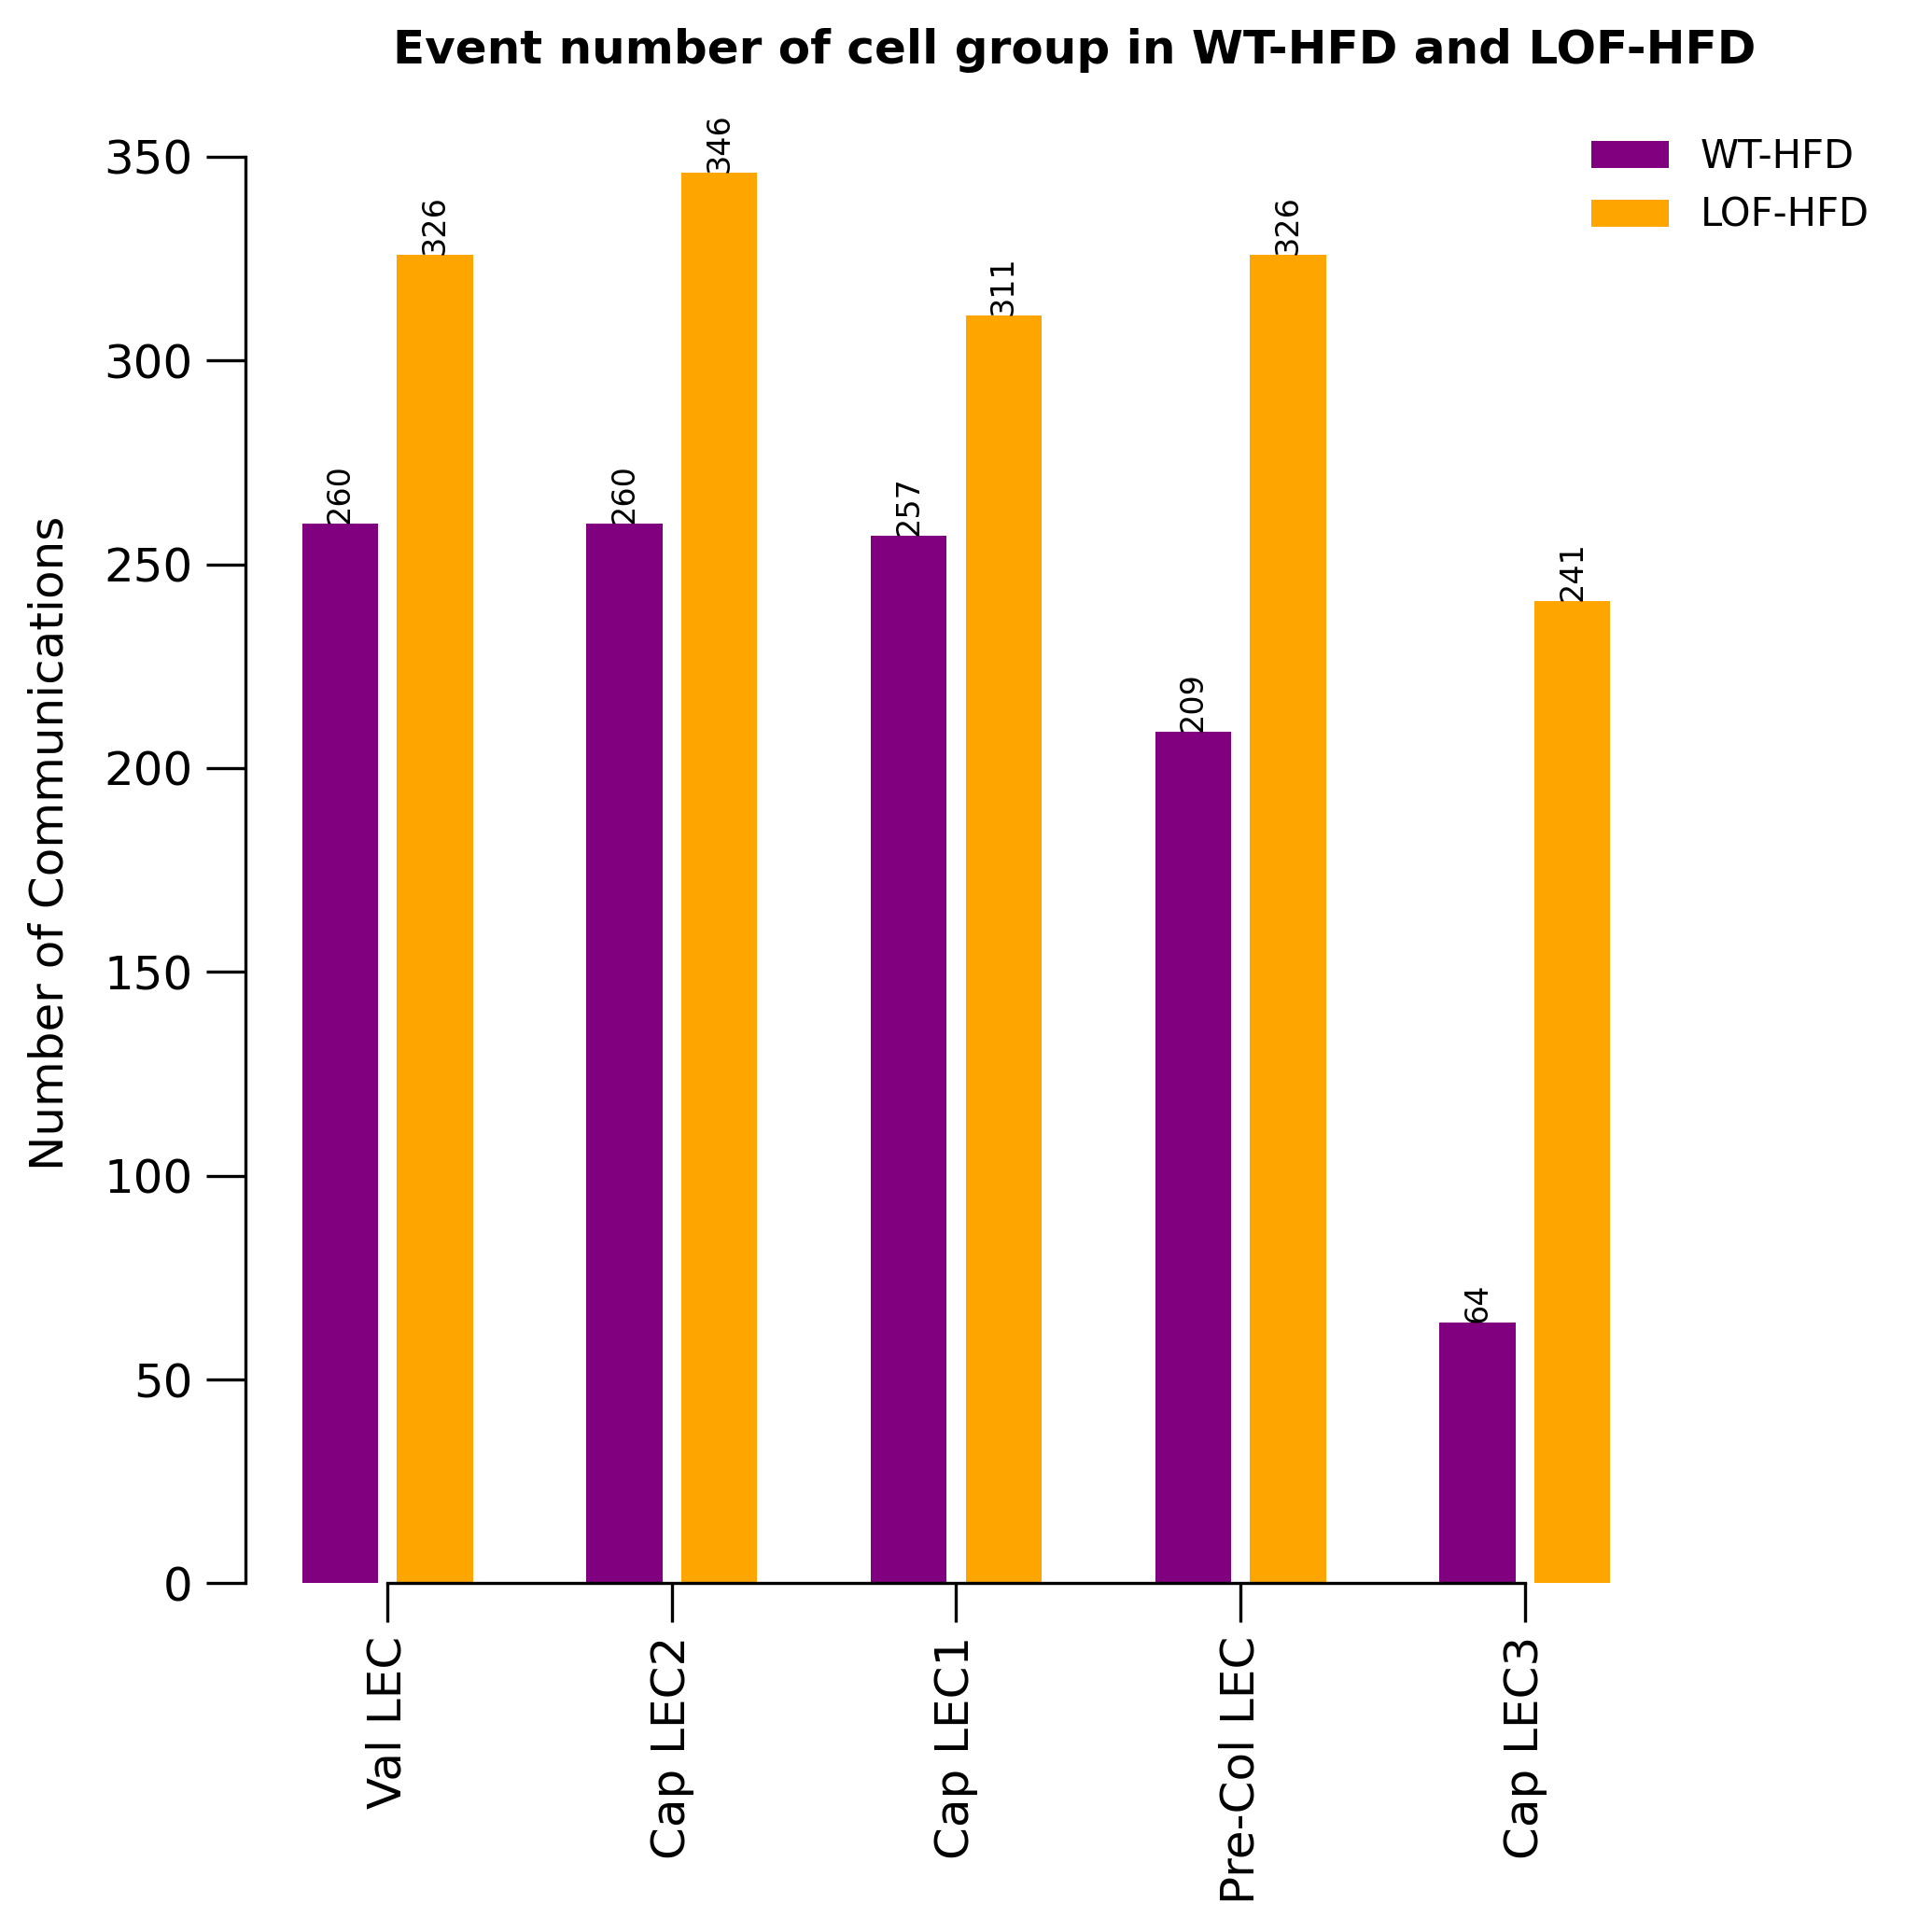

In [7]:
mebo_obj = mebocost.load_obj(processedDataDir+'_commu_1.pk')
## focus on communications in same condition
commu_res = mebo_obj.commu_res.copy()
commu_res
##### you should modify this chunk of code by your data, here I write this as my cell group labeled as celltype~condition
commu_res['sender_cond'] = [x.split('_')[-1] for x in commu_res['Sender'].tolist()]
commu_res['receiver_cond'] = [x.split('_')[-1] for x in commu_res['Receiver'].tolist()]
commu_res_new = pd.DataFrame()
for c in commu_res['sender_cond'].unique().tolist():
    tmp = commu_res[(commu_res['sender_cond'] == c) & (commu_res['receiver_cond'] == c)]
    commu_res_new = pd.concat([commu_res_new, tmp])
print(commu_res_new['sender_cond'].value_counts())
commu_res_new_WT = commu_res_new[commu_res_new['sender_cond']=='WT-HFD'].copy()
commu_res_new_DKO = commu_res_new[commu_res_new['sender_cond']=='LOF-HFD'].copy()
# mebo_obj.commu_res


#### combine two condition to compare total communications 
WT_sig = commu_res_new_WT[(commu_res_new_WT['permutation_test_fdr']<=1) &
                           (commu_res_new_WT['Commu_Score']>0.05)]

WT_cell_type_count = collections.Counter(WT_sig['Sender'].tolist()+WT_sig['Receiver'].tolist())
WT_cell_type_count = pd.Series(WT_cell_type_count)
WT_cell_type_count.index = [x.split('_')[0] for x in WT_cell_type_count.index.tolist()]


DKO_sig = commu_res_new_DKO[(commu_res_new_DKO['permutation_test_fdr']<=1) &
                           (commu_res_new_DKO['Commu_Score']>0.05)]
DKO_cell_type_count = collections.Counter(DKO_sig['Sender'].tolist()+DKO_sig['Receiver'].tolist())
DKO_cell_type_count = pd.Series(DKO_cell_type_count)
DKO_cell_type_count.index = [x.split('_')[0] for x in DKO_cell_type_count.index.tolist()]


cell_type_count = pd.concat([WT_cell_type_count, DKO_cell_type_count], axis = 1)#.reset_index()
cell_type_count=cell_type_count.fillna(0)


cell_type_count.columns = ['WT-HFD', 'LOF-HFD']
cell_type_count = cell_type_count.sort_values('WT-HFD', ascending=False)

## plot

df = cell_type_count.copy()
nrow, ncol = df.shape

figsize = (7, 7)
if figsize == 'auto':
    Figsize = (3+nrow*0.25, 2.5+nrow*0.15)
else:
    Figsize = figsize

fig, ax = plt.subplots(figsize = Figsize)

colmap = {'WT-HFD': 'purple', 'LOF-HFD': 'orange'}

xtick = list(np.arange(0, nrow * 3, 3))
xtick1 = list(np.arange(0, nrow * 3, 3) - 0.5)
xtick2 = list(np.arange(0, nrow * 3, 3) + 0.5)

ax.bar(xtick1, df['WT-HFD'], 
            color = colmap['WT-HFD'],
           label = 'WT-HFD')
ax.bar(xtick2, df['LOF-HFD'], 
            color = colmap['LOF-HFD'],
           label = 'LOF-HFD')
for i in range(len(xtick1)):
    ax.text(x=xtick1[i], y=df.iloc[i]['WT-HFD'],
            s=int(df.iloc[i]['WT-HFD'])+0,
            rotation = 90, 
            ha = 'center',
            va = 'bottom',
            fontsize = 8
           )
for i in range(len(xtick2)):
    ax.text(x=xtick2[i], y=df.iloc[i]['LOF-HFD'],
            s=int(df.iloc[i]['LOF-HFD'])+0,
            rotation = 90, 
            ha = 'center',
            va = 'bottom',
            fontsize = 8
           )
plt.xticks(ticks = xtick,
                 labels = df.index.tolist())

ax.tick_params(axis = 'x', which = 'major',
               rotation = 90, size = 10)
ax.tick_params(axis = 'y', which = 'major',
               rotation = 0, size = 10)
ax.set_xlabel('')
ax.set_ylabel('Number of Communications', size = 12)
ax.set_title('Event number of cell group in WT-HFD and LOF-HFD',
            pad = 10, fontweight = 'bold')
sns.despine(trim = True)
ax.legend(#bbox_to_anchor=(1, .9),
             frameon = False,
          fontsize = 10)
ax.set_xlim(-1.5, nrow*3+1)
plt.tight_layout()
plt.savefig('barplot_total_communication_WT-HFD_vs_LOF-HFD.pdf')


plt.show()
plt.close()

### 2.5.2 summay of communication in cell-to-cell network

In [8]:
def _filter_lowly_aboundant_(self, 
                                 pvalue_res,
                                 cutoff_prop,
                                 met_prop=None,
                                 exp_prop=None,
                                 min_cell_number=50
                                ):
        """
        change p value to 1 if either metabolite_prop or transporter_prop equal to 0 
        (meaning that no metabolite or transporter level in the cluster)
        """
        res = pvalue_res.copy()
        ## add the metabolite abudance proportion
        if met_prop is not None:
            res['metabolite_prop_in_sender'] = [met_prop.loc[s, m] for s, m in res[['Sender', 'Metabolite']].values.tolist()]
        ## add the metabolite abudance proportion
        if exp_prop is not None:
            res['sensor_prop_in_receiver'] = [exp_prop.loc[r, s] for r, s in res[['Receiver', 'Sensor']].values.tolist()]
        
        if 'original_result' not in list(vars(self)):
            self.original_result = res.copy()
        ## minimum cell number
        cell_count = pd.Series(dict(collections.Counter(self.cell_ann['cell_group'].tolist())))
        bad_cellgroup = cell_count[cell_count<min_cell_number].index.tolist() 
        
        info('Set p value and fdr to 1 if sensor or metaboltie expressed cell proportion less than {}'.format(cutoff_prop))
        bad_index = np.where((res['metabolite_prop_in_sender'] <= cutoff_prop) |
                             (res['sensor_prop_in_receiver'] <= cutoff_prop) |
                             (res['Commu_Score'] < 0) |
                             (res['Sender'].isin(bad_cellgroup)) | 
                             (res['Receiver'].isin(bad_cellgroup))
                            )[0]
        if len(bad_index) > 0:
            pval_index = np.where(res.columns.str.endswith('_pval'))[0]
            res.iloc[bad_index, pval_index] = 1 # change to 1
            fdr_index = np.where(res.columns.str.endswith('_fdr'))[0]
            res.iloc[bad_index, fdr_index] = 1 # change to 1
        
        ## norm communication score
        res['Commu_Score'] = res['Commu_Score']/np.array(res['bg_mean']).clip(min = 0.05)
        
        ## reorder columns
        columns = ['Sender', 'Metabolite', 'Metabolite_Name', 
                   'Receiver', 'Sensor', 'Commu_Score', 
                   'metabolite_prop_in_sender',
                   'sensor_prop_in_receiver', 
#                    'bg_mean', 'bg_std',
                   'ztest_stat', 'ztest_pval', 'ttest_stat',
                   'ttest_pval', 'ranksum_test_stat', 'ranksum_test_pval',
                   'permutation_test_stat', 'permutation_test_pval',
                   'ztest_fdr', 'ttest_fdr', 'ranksum_test_fdr',
                   'permutation_test_fdr']
        get_columns = [x for x in columns if x in res.columns.tolist()]
        res = res.reindex(columns = get_columns).sort_values('permutation_test_fdr')
        return(res)

In [9]:
## differential flow plot
cellall_mebo = mebocost.load_obj(processedDataDir+'_commu_1.pk')

min_cell_number = 3
commu_res_tmp = cellall_mebo._filter_lowly_aboundant_(pvalue_res=cellall_mebo.original_result.copy(),
                                                    cutoff_prop=0.001,
                                                    met_prop=cellall_mebo.met_prop,
                                                    exp_prop=cellall_mebo.exp_prop,
                                                    min_cell_number=min_cell_number)
cell_count = pd.Series(dict(cellall_mebo.cell_ann.groupby('cell_group')['cell_group'].count()))
bad_cell = cell_count[cell_count<min_cell_number].index
commu_res_tmp = commu_res_tmp[~commu_res_tmp['Sender'].isin(bad_cell) & ~commu_res_tmp['Receiver'].isin(bad_cell)]


## focus on communications in same condition
commu_res = commu_res_tmp.copy() #cellall_mebo.commu_res.copy()
##### you should modify this chunk of code by your data, here I write this as my cell group labeled as celltype~condition
commu_res['sender_cond'] = [x.split('_')[-1] for x in commu_res['Sender'].tolist()]
commu_res['receiver_cond'] = [x.split('_')[-1] for x in commu_res['Receiver'].tolist()]
commu_res_new = pd.DataFrame()
for c in commu_res['sender_cond'].unique().tolist():
    tmp = commu_res[(commu_res['sender_cond'] == c) & (commu_res['receiver_cond'] == c)]
    commu_res_new = pd.concat([commu_res_new, tmp])

cellall_mebo.commu_res = commu_res_new.copy()

## find significant communication in at least one condition
commu_res_new['label'] = commu_res_new['Sender'].apply(lambda x: x.split('_')[0])+'_'+commu_res_new['Metabolite_Name']+'_'+commu_res_new['Sensor']+'_'+commu_res_new['Receiver'].apply(lambda x: x.split('_')[0])
significant = commu_res_new[commu_res_new['permutation_test_fdr'] < 0.05]
### significant
commu_res_need = commu_res_new.copy() #[commu_res_new['label'].isin(significant['label'])]

commu_res_need_mat = commu_res_need.pivot_table(index = 'label', columns = 'sender_cond', values = 'Commu_Score')

commu_res_need_mat['delta'] = commu_res_need_mat['LOF-HFD'] - commu_res_need_mat['WT-HFD']

ann = pd.DataFrame(commu_res_need_mat.index.str.split('_').values.tolist(),
            index = commu_res_need_mat.index,
            columns = ['Sender', 'Metabolite_Name', 'Sensor', 'Receiver'])

commu_res_need_mat = pd.concat([commu_res_need_mat, ann], axis = 1)
# print(commu_res_need_mat.Metabolite_Name.unique())

[July 23, 2026 15:10:55]: Data Preparation Done in 0.0164 seconds
[July 23, 2026 15:10:55]: Set p value and fdr to 1 if sensor or metaboltie expressed cell proportion less than 0.001


In [10]:
"""commu_res_tmp=commu_res_tmp[commu_res_tmp.Metabolite_Name.str.contains("Cholesterol|Cytidine|25-Hydroxycholesterol")]
commu_res_tmp=commu_res_tmp[commu_res_tmp.Sensor.str.contains("Cd36|Slc2a1|Ldlr|Lrp1")]



commu_res_tmp.query('permutation_test_fdr < 0.01').sort_values('Commu_Score')
commu_res_tmp

top_n = commu_res_need_mat.delta.abs().sort_values().tail(500).index
top_n"""

'commu_res_tmp=commu_res_tmp[commu_res_tmp.Metabolite_Name.str.contains("Cholesterol|Cytidine|25-Hydroxycholesterol")]\ncommu_res_tmp=commu_res_tmp[commu_res_tmp.Sensor.str.contains("Cd36|Slc2a1|Ldlr|Lrp1")]\n\n\n\ncommu_res_tmp.query(\'permutation_test_fdr < 0.01\').sort_values(\'Commu_Score\')\ncommu_res_tmp\n\ntop_n = commu_res_need_mat.delta.abs().sort_values().tail(500).index\ntop_n'

In [11]:
import networkx as nx
from adjustText import adjust_text

def _make_comm_event_(commu_res,
                        pval_method = 'permutation_test_fdr',
                        pval_cutoff = 0.05,
                        comm_score_col = 'Commu_Score',
                        comm_score_cutoff = None,
                        cutoff_prop = None
                     ):
    
    plot_tmp = commu_res.copy()
    plot_tmp['Signal_Pair'] = plot_tmp['Metabolite_Name'] + '_' + plot_tmp['Sensor']
    plot_tmp['Cell_Pair'] = plot_tmp['Sender'] + '→' + plot_tmp['Receiver']
    
    if comm_score_cutoff:
        plot_tmp = plot_tmp[plot_tmp[comm_score_col].abs() > comm_score_cutoff]
    
    if plot_tmp.shape[0] == 0:
        info('No communication events under pval_cutoff:{} and comm_score_cutoff:{}, try to tune them!'.format(pval_cutoff, comm_score_cutoff))
        return None
    ## visulize the communication frequency between cells
    count_df = pd.DataFrame(plot_tmp.groupby('Cell_Pair')['Cell_Pair'].count())
    count_df.index = count_df.index.tolist()
    count_df = pd.concat([count_df, 
                          pd.DataFrame(count_df.index.str.split('→').tolist(), index = count_df.index)], axis = 1)
    count_df.columns = ['Count', 'Sender', 'Receiver']
    ## communicate event summary
    comm_event = {}
    for x in plot_tmp['Cell_Pair'].tolist():
        tmp = plot_tmp[plot_tmp['Cell_Pair']==x]['delta'] # all the p values
        comm_event[x] = [len(tmp), np.median(tmp)] # -sum(-tmp)] ## sum of log p = the product of p
    comm_event = pd.DataFrame.from_dict(comm_event, orient = 'index')
    comm_event = pd.concat([comm_event, 
                            pd.DataFrame(comm_event.index.str.split('→').tolist(), index = comm_event.index)], axis = 1)
    comm_event.columns = ['Count', 'delta', 'Sender', 'Receiver']
    return(comm_event)

def _commu_network_plot_(commu_res,
                        sender_focus = [],
                        metabolite_focus = [],
                        sensor_focus = [],
                        receiver_focus = [],
                        remove_unrelevant = False,
                        and_or = 'and',
                        pval_method = 'permutation_test_fdr',
                        pval_cutoff = 0.05,
                        node_cmap = 'tab20',
                        figsize = 'auto',
                        line_cmap = 'RdBu_r',
                        line_color_vmin = None,
                        line_color_vmax = None,
                        line_width_col = 'Count',
                        linewidth_norm = (0.1, 1),
                        node_size_norm = (50, 300),
                        adjust_text_pos_node = True,
                        node_text_hidden = False,
                        node_text_font = 10,
                        pdf = None,
                        save_plot = True,
                        show_plot = False,
                        comm_score_col = 'Commu_Score',
                        comm_score_cutoff = None,
                        cutoff_prop = None,
                        text_outline = False,
                        return_fig = False):
    """
    plot network figure to show the interactions between cells
    --------------
    comm_event: a data frame with the format like this:
                                    Count   -log10(pvalue)  Sender  Receiver
        Malignant_0->Malignant_0    13  17.864293   Malignant_0 Malignant_0
        Malignant_12->Malignant_0   16  21.788151   Malignant_12    Malignant_0
        Malignant_1->Malignant_0    10  13.598459   Malignant_1 Malignant_0
    line_cmap: line color map, usually for the overall confidence (-log10(pvalue)) for the connection
    node_cmap: node color map, usually for different type of cells
    figsize: a tuple to indicate the width and height for the figure, default is automatically estimate
    sender_col: column names for sender cells
    receiver_col: column names for sender cells
    """
#     info('show communication in cells by network plot')

    ## clean
    plt.close()
    
    sender_col = 'Sender'
    receiver_col = 'Receiver'
    metabolite_col = 'Metabolite_Name'
    sensor_col = 'Sensor'
    line_color_col = 'delta'
    
    ## adjust by filter
    focus_commu = commu_res.copy()
    if and_or == 'and':
        if sender_focus:
            focus_commu = focus_commu[(focus_commu[sender_col].isin(sender_focus))]
        if receiver_focus:
            focus_commu = focus_commu[(focus_commu[receiver_col].isin(receiver_focus))]
        if metabolite_focus:
            focus_commu = focus_commu[(focus_commu[metabolite_col].isin(metabolite_focus))]
        if sensor_focus:
            focus_commu = focus_commu[(focus_commu[sensor_col].isin(sensor_focus))]
    else:
        if sender_focus or receiver_focus or metabolite_focus or sensor_focus:
            focus_commu = focus_commu[(focus_commu[sender_col].isin(sender_focus)) |
                                     (focus_commu[receiver_col].isin(receiver_focus)) |
                                     (focus_commu[metabolite_col].isin(metabolite_focus)) |
                                     (focus_commu[sensor_col].isin(sensor_focus))]
    if focus_commu.shape[0] == 0:
        info('No communication detected under the filtering')
                                     
    if remove_unrelevant is True:
        ## make comm_event
        comm_event = _make_comm_event_(
                                commu_res = focus_commu,
                                pval_method = pval_method,
                                pval_cutoff = pval_cutoff,
                                comm_score_col = comm_score_col,
                                comm_score_cutoff = comm_score_cutoff,
                                cutoff_prop = cutoff_prop
                            )
    else:
        ## make comm_event
        comm_event = _make_comm_event_(
                                commu_res = commu_res,
                                pval_method = pval_method,
                                pval_cutoff = pval_cutoff,
                                comm_score_col = comm_score_col,
                                comm_score_cutoff = comm_score_cutoff,
                                cutoff_prop = cutoff_prop
                            )
        
    if comm_event is None:
        return
    
    if figsize == 'auto' or not figsize:
        node_num = len(set(comm_event[sender_col].tolist()+comm_event[receiver_col].tolist()))
        figsize = (2.8+node_num*0.2, 1.8+node_num * 0.1)

    fig = plt.figure(constrained_layout=True, figsize=figsize)

    subfigs = fig.add_gridspec(2, 3, width_ratios=[5.2, .7, .7])
    leftfig = fig.add_subplot(subfigs[:, 0])
    midfig = [fig.add_subplot(subfigs[0, 1]), fig.add_subplot(subfigs[1, 1])]
    rightfig = fig.add_subplot(subfigs[:, 2])

    ## get the node cells
    total_count = collections.Counter(comm_event[receiver_col].tolist()+comm_event[sender_col].tolist())
    G = nx.DiGraph(directed = True)

    ## add node
    for n in sorted(list(total_count.keys())):
        G.add_node(n)
        
    ## node size and color
    node_size_norm_fun = lambda x, y: node_size_norm[0]+((x-min(y)) / (max(y) - min(y)) * (node_size_norm[1]-node_size_norm[0])) if max(y) != min(y) else node_size_norm[0]+((x-min(y)) / max(y) * (node_size_norm[1]-node_size_norm[0])) 
    
    node_size = [node_size_norm_fun(total_count.get(x, 0), total_count.values()) for x in G.nodes()] 

    if type(node_cmap) == type(dict()):
        node_col = np.array([node_cmap.get(x) for x in G.nodes()])
    else:
        node_col = np.array([plt.cm.get_cmap(node_cmap)(i) for i in range(len(G.nodes()))])


#     linewidth_norm_fun = lambda x, y: linewidth_norm[0]+((x-min(y)) / (max(y) - min(y)) * (linewidth_norm[1]-linewidth_norm[0])) if max(y) != min(y) else linewidth_norm[0]+((x-min(y)) / max(y) * (linewidth_norm[1]-linewidth_norm[0]))
    edge_color_norm = matplotlib.colors.Normalize(vmin = line_color_vmin if line_color_vmin else comm_event[line_color_col].min(), vmax = line_color_vmax if line_color_vmax else comm_event[line_color_col].max())

    if focus_commu.shape[0] == 0:
        # Custom the nodes:
        pos = nx.circular_layout(G)
        nx.draw(G, pos, #with_labels=with_labels,
                font_size = node_text_font, node_color=node_col,
                node_size=node_size, 
                cmap = node_cmap, ax = leftfig, alpha = .9)
    else:
        comm_event_filter = _make_comm_event_(
                                        commu_res = focus_commu,
                                        pval_method = pval_method,
                                        pval_cutoff = pval_cutoff,
                                        comm_score_col = comm_score_col,
                                        comm_score_cutoff = comm_score_cutoff
                                    )
        if comm_event_filter is None:
            return
        
        for i,line in comm_event_filter.iterrows():
            sender = line[sender_col]
            receiver = line[receiver_col]
            G.add_edge(sender, receiver)

        # Custom the nodes:
        pos = nx.circular_layout(G)

        if not line_color_vmin:
            line_color_vmin = np.percentile(comm_event[line_color_col], 0)
        if not line_color_vmax:
            line_color_vmax = np.percentile(comm_event[line_color_col], 100)
        
        
        edge_color = [plt.cm.get_cmap(line_cmap)(edge_color_norm(comm_event[(comm_event[sender_col]==x[0]) &
                                  (comm_event[receiver_col]==x[1])].iloc[0][line_color_col])) for x in G.edges]

#         linewidth = [linewidth_norm_fun(comm_event[(comm_event[sender_col]==x[0]) & 
#                                                    (comm_event[receiver_col]==x[1])].loc[:, line_width_col],
#                                         comm_event[line_width_col]) for x in G.edges]
        nx.draw(G, pos, 
#                 with_labels=with_labels,
                arrows = True, 
                arrowstyle = '-|>',
                font_size = node_text_font,
                node_color=node_col,
                node_size=node_size, 
                edge_color=edge_color, 
#                 width=linewidth,
#                 cmap = node_cmap, 
                ax = leftfig, alpha = .8)
        
    if node_text_hidden is False or node_text_hidden is None:
        if adjust_text_pos_node:
            text = []
            for x in pos.keys():
                txt = leftfig.text(pos[x][0], pos[x][1], x, size = node_text_font)
                if text_outline:
                    txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])
                text.append(txt)

            adjust_text(text, 
                        # arrowprops=dict(arrowstyle="-", color = 'k'),
                        ax = leftfig
                        )   
        else:
            for x in pos.keys():
                txt = leftfig.text(pos[x][0], pos[x][1], x, size = node_text_font, ha = 'center')
                if text_outline:
                    txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])

    ## node size
    node_size_ann = sorted(list(set([np.percentile(list(total_count.values()), 10),
                    np.percentile(list(total_count.values()), 50),
                    np.percentile(list(total_count.values()), 90)])))
    ## legend for connected node size
    for label in node_size_ann:
        midfig[0].scatter([],[],
                color = 'black',
                facecolors='none',
                s = node_size_norm_fun(label, node_size_ann),
                label=int(label))
    ## legend for communication evens, line width
    line_ann = sorted(list(set([np.min(comm_event[line_width_col]),
                    np.percentile(comm_event[line_width_col], 50),
                    np.max(comm_event[line_width_col])])))

#     for label in line_ann:
#         midfig[1].plot([],[],'g',
#                 color = 'black',
#                 linewidth = linewidth_norm_fun(label, line_ann),
#                 label=int(label))
    midfig[0].axis('off')
    midfig[1].axis('off')
    midfig[0].legend(title = '# of\nConnected\nNodes', loc='center', frameon = False)
#     midfig[1].legend(title = '# of\nCommunication\nEvents', loc='center', frameon = False)
    ## legend for communication confidence, line color
    sm = matplotlib.cm.ScalarMappable(cmap=plt.cm.get_cmap(line_cmap), norm = edge_color_norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, shrink = .5, location = 'left')
    cbar.set_label(label='Median Delta Communication Score\n(D374Y - control)',fontsize = 10) #control - D374Y
    rightfig.axis('off')
    pdf.savefig(fig) if pdf else None
    if show_plot:
        plt.show()
    plt.close()
    if return_fig:
        return(fig)

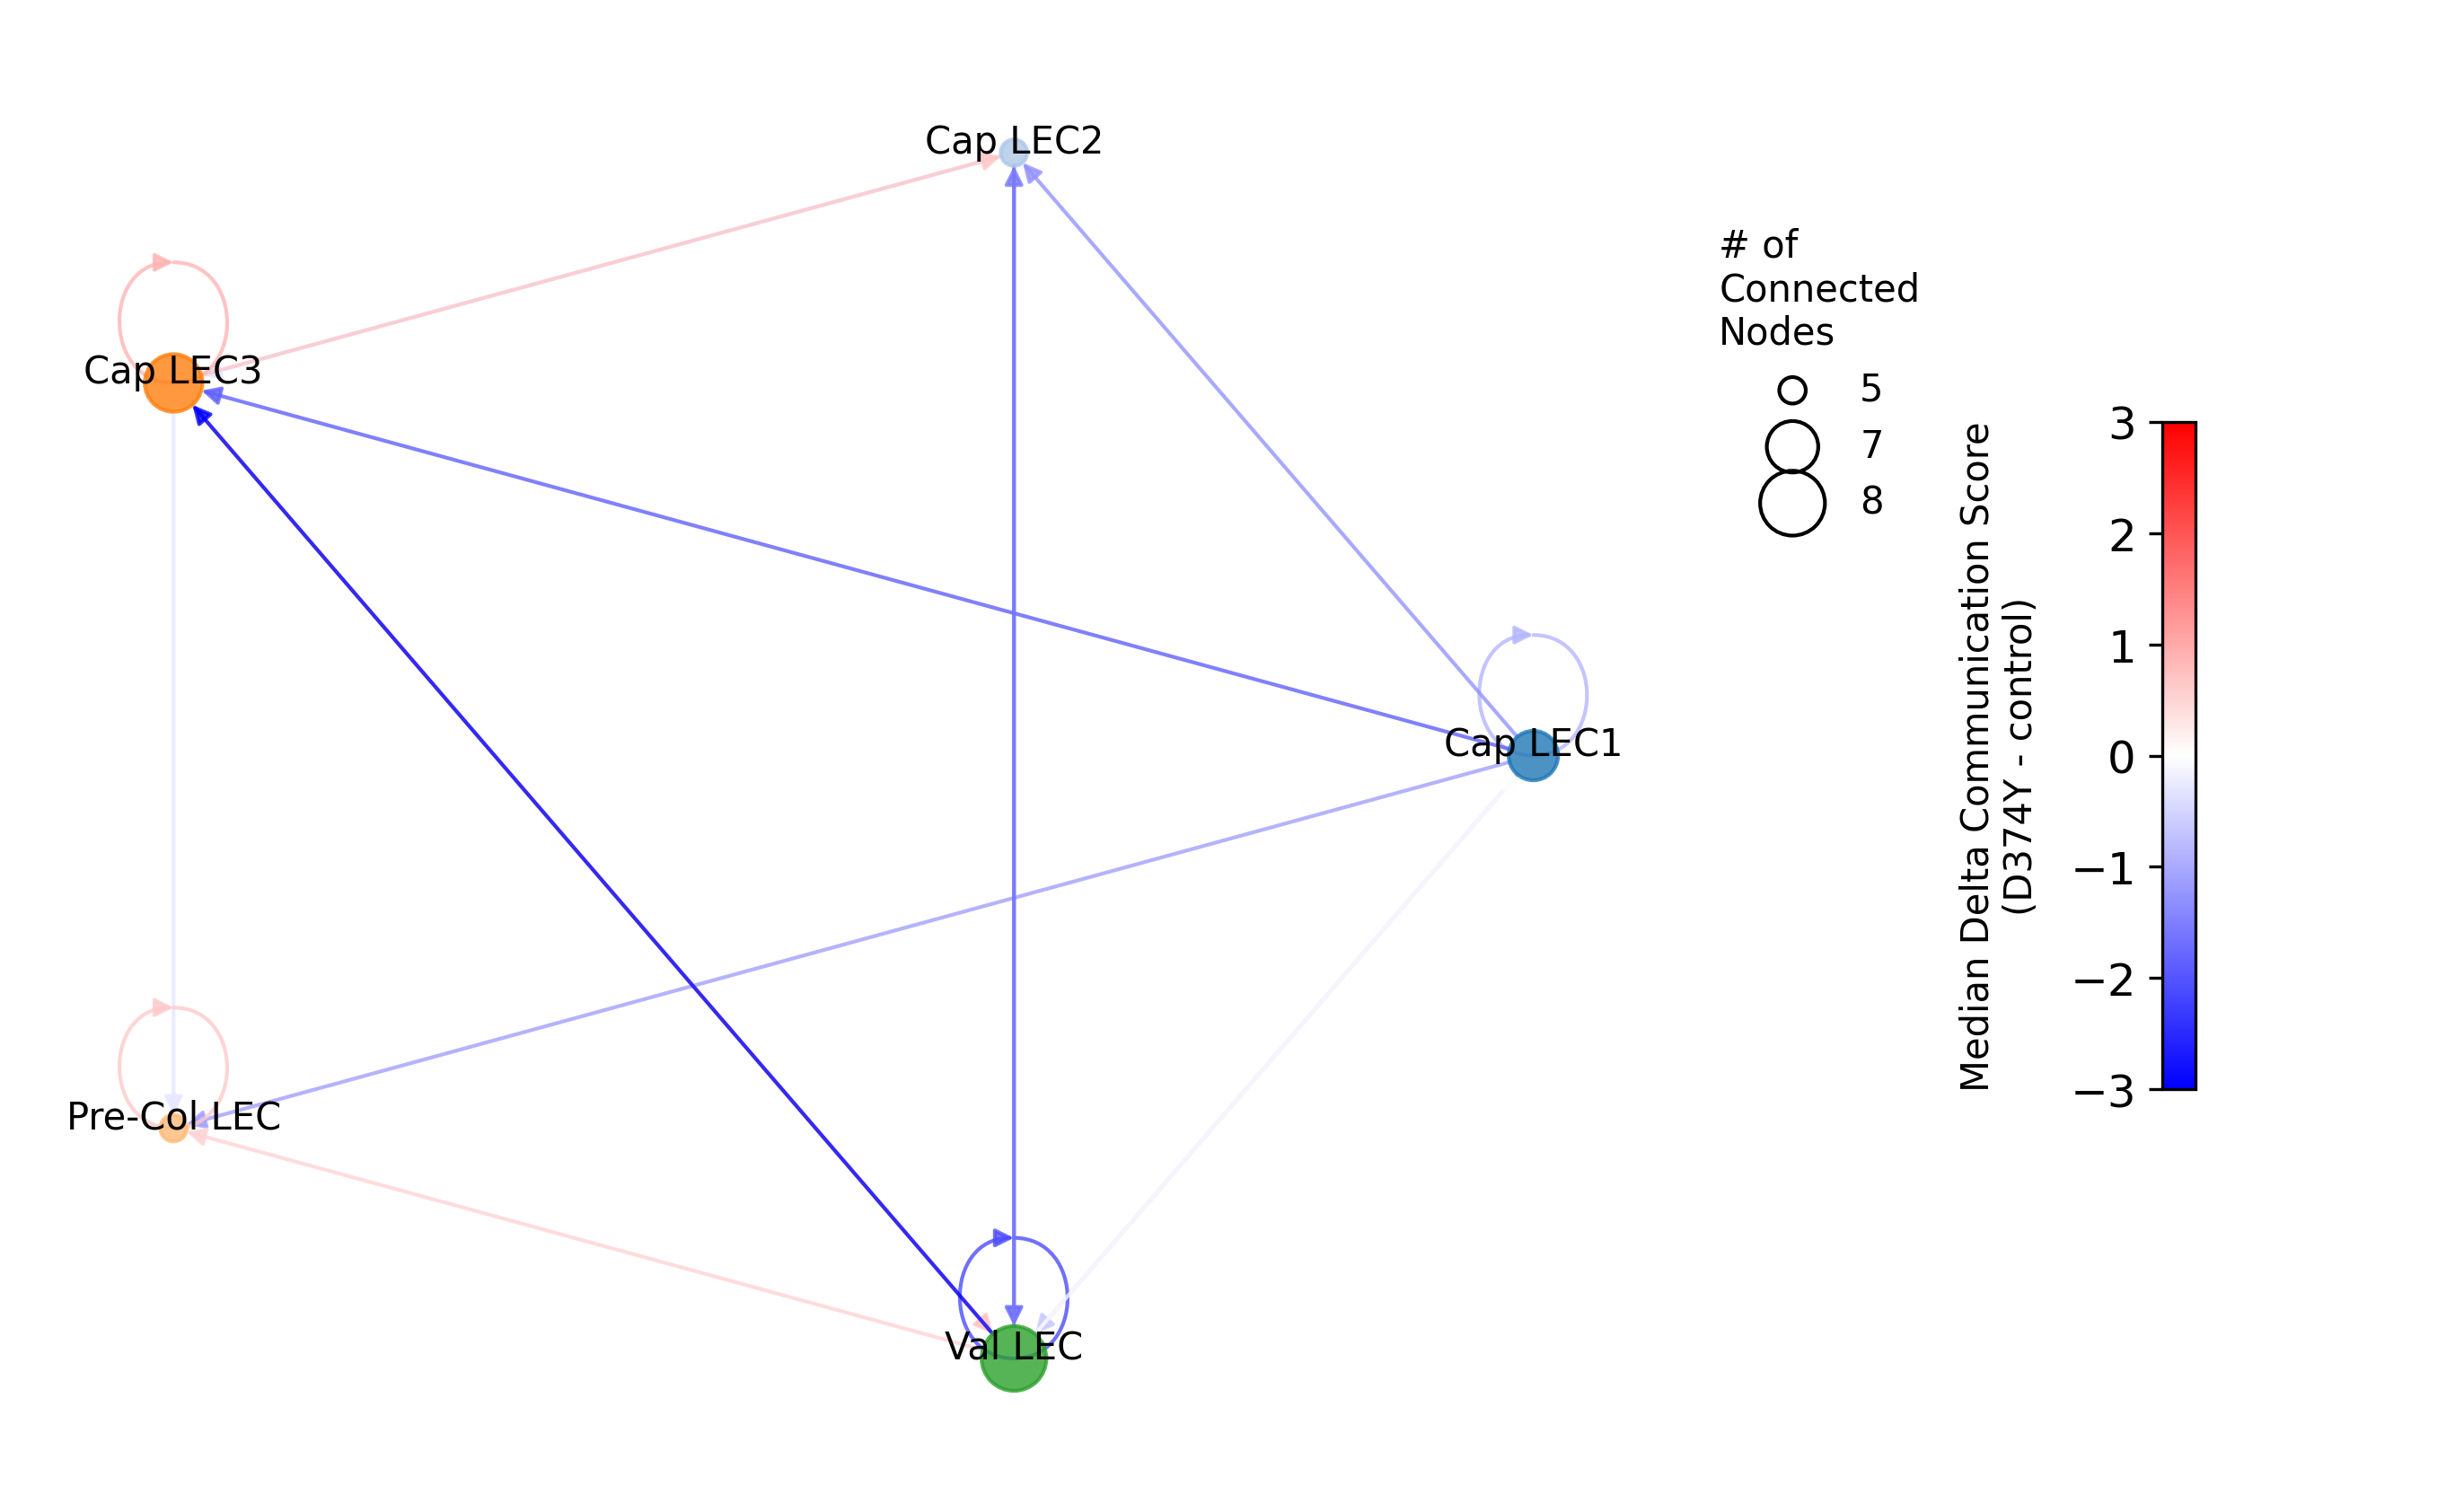

In [12]:
p3 = _commu_network_plot_(commu_res=commu_res_need_mat,
                        sender_focus = [],
                        metabolite_focus =[],# ["Cholesterol","Cytidine""25-Hydroxycholesterol"],
                        sensor_focus =[],# ["Cd36","Slc2a1","Ldlr","Lrp1"],
                        receiver_focus = [],
                        remove_unrelevant = False,
                        and_or = 'or',
                        pval_method = 'permutation_test_fdr',
                        pval_cutoff =1,
                        node_cmap = 'tab20',
                        figsize = (9, 5.5),
                        line_cmap = 'bwr',
                        line_color_vmin = -3,
                        line_color_vmax = 3,
                        line_width_col = 'Count',
                        linewidth_norm = (0.1, 1),
                        node_size_norm = (50, 300),
                        adjust_text_pos_node = False,
                        node_text_hidden = False,
                        node_text_font = 10,
                        pdf = None,
                        save_plot = False,
                        show_plot = True,
                        comm_score_col = 'delta',
                        comm_score_cutoff = 0.5,
                        cutoff_prop = None,
                        text_outline = False,
                        return_fig = True)
p3.savefig("differenital_comm_ALL_Delta_communication_score_LOF-HFD_WT-HFD_circleplot.pdf")

In [13]:
def _FlowPlot_(comm_res, 
                pval_method='permutation_test_fdr',
                pval_cutoff=1,
                sender_focus = [],
                metabolite_focus =[],# ["Cholesterol","Cytidine""25-Hydroxycholesterol"],
                sensor_focus =[],# ["Cd36","Slc2a1","Ldlr","Lrp1"],
                receiver_focus = [],
                remove_unrelevant = False,
                and_or = 'and',
                node_label_size = 8,
                node_alpha = .8,
                figsize = 'auto',
                node_cmap = 'Set1',
                line_cmap = 'spring_r',
                line_vmin = None,
                line_vmax = None,
                linewidth_norm = (0.1, 1),
                node_size_norm = (10, 150),
                pdf=None, 
                save_plot = True, 
                show_plot = False,
                comm_score_col = 'Commu_Score',
                comm_score_cutoff = None,
                cutoff_prop = None,
                text_outline = False,
                return_fig = False):
    """
    plot the flux plot to connect sender - metabolite - sensor - receiver
    ------------
    commu_res: a data frame containing all the communication events
    pval_method: a string, default using permutation_test_fdr, but ttest_pval was also supported 
    cutoff: the p value cutoff, the default will be 0.05
    node_label_size: the font size to label the node
    node_alpha: transpency for the node dots
    figsize: the figsize in tuple format
    node_cmap: color map used to draw node
    line_cmap: color map used to distinguish communication significance in line color
    line_vmin and line_vmax: set the colormap scale for line color, default both None
    node_size_norm: node size tells the connection numbers, can be set to normalize into a range
    linewidth_norm: linewidth to show the 
    prefix: a string, specefy where to save the figure, default the current directory
    """
    ## clean
    plt.close()
    
#     info('plot flow plot to show the communications from Sender -> Metabolite -> Sensor -> Receiver')
    Sender_col = 'Sender'
    Receiver_col = 'Receiver'
    metabolite_col = 'Metabolite_Name'
    sensor_col = 'Sensor'
    line_color_col = 'delta'


    ## get matrix
    plot_tmp = comm_res.copy()
    if comm_score_cutoff:
        plot_tmp = plot_tmp[plot_tmp[comm_score_col].abs()>comm_score_cutoff]
    
    focus_plot = plot_tmp.copy()
    if and_or == 'and':
        if sender_focus:
            focus_plot = focus_plot[(focus_plot[Sender_col].isin(sender_focus))]
        if receiver_focus:
            focus_plot = focus_plot[(focus_plot[Receiver_col].isin(receiver_focus))]
        if metabolite_focus:
            focus_plot = focus_plot[(focus_plot[metabolite_col].isin(metabolite_focus))]
        if sensor_focus:
            focus_plot = focus_plot[(focus_plot[sensor_col].isin(sensor_focus))]
    else:
        if sender_focus or receiver_focus or metabolite_focus or sensor_focus:
            focus_plot = focus_plot[(focus_plot[Sender_col].isin(sender_focus)) |
                                     (focus_plot[Receiver_col].isin(receiver_focus)) |
                                     (focus_plot[metabolite_col].isin(metabolite_focus)) |
                                     (focus_plot[sensor_col].isin(sensor_focus))]
    
    if remove_unrelevant:
        plot_tmp = focus_plot.copy()
        
    ## get count to define dot size
    sender_count = dict(collections.Counter(plot_tmp['Sender']))
    receiver_count = dict(collections.Counter(plot_tmp['Receiver']))
    metabolite_count = dict(collections.Counter(plot_tmp['Metabolite_Name']))
    sensor_count = dict(collections.Counter(plot_tmp['Sensor']))
    ## all count to set dot size scale
    all_count = list(sender_count.values())+list(receiver_count.values())+list(metabolite_count.values())+list(sensor_count.values())
    # sender, receiver, uniquely
    senders = sorted(plot_tmp['Sender'].unique().tolist())
    receivers = sorted(plot_tmp['Receiver'].unique().tolist())
    metabolites = sorted(plot_tmp['Metabolite_Name'].unique().tolist())
    sensors = sorted(plot_tmp['Sensor'].unique().tolist())
    ## y maximum
    max_y = max([len(senders), len(receivers), len(metabolites), len(sensors)])
    senders_inti = int(abs(max_y-len(senders))/2) if abs(max_y-len(senders)) != 0 else 0
    receivers_inti = int(abs(max_y-len(receivers))/2) if abs(max_y-len(receivers)) != 0 else 0
    metabolites_inti = int(abs(max_y-len(metabolites))/2) if abs(max_y-len(metabolites)) != 0 else 0
    sensors_inti = int(abs(max_y-len(sensors))/2) if abs(max_y-len(sensors)) != 0 else 0
    # node size shows the connection number
    node_size_norm_fun = lambda x, y: node_size_norm[0]+((x-min(y)) / (max(y) - min(y)) * (node_size_norm[1]-node_size_norm[0])) if max(y) != min(y) else node_size_norm[0]+((x-min(y)) / max(y) * (node_size_norm[1]-node_size_norm[0])) 
    # figsize
    if figsize == 'auto' or not figsize:
        figsize = (12, 5+max_y*0.07)
    # build up figure layout
    fig = plt.figure(constrained_layout=True, figsize=figsize)
    subfigs = fig.add_gridspec(3, 4, height_ratios=[5, 1.2, 0.1],
                              hspace = 0, wspace = 0)
    main = fig.add_subplot(subfigs[0, :])
    bottom_left = fig.add_subplot(subfigs[1, 0])
    bottom_leftb = fig.add_subplot(subfigs[2, 0])
    mid = fig.add_subplot(subfigs[1:2, 1])
    bottom_mid = fig.add_subplot(subfigs[1:2, 2])
    bottom_right = fig.add_subplot(subfigs[1:2, 3])
    ## hiden axis
    main.axis('off')
    bottom_left.axis('off')
    mid.axis('off')
    bottom_leftb.axis('off')
    bottom_mid.axis('off')
    bottom_right.axis('off')
    
    ## node color
    if type(node_cmap) == type(list()) and len(node_cmap) == 4:
        sc, mc, ssc, rrc = node_cmap
    else:
        sc, mc, ssc, rrc = plt.cm.get_cmap(node_cmap)(1), plt.cm.get_cmap(node_cmap)(2), plt.cm.get_cmap(node_cmap)(3), plt.cm.get_cmap(node_cmap)(4)
    
    def _loc_(i, r, a):
        if a == 1:
            return([i])
        l = [i]
        for x in range(1, a):
            i += r
            l.append(i)
        return(l)

    ## draw dot for sender
    m_to_sender_ratio = int(.5*len(metabolites)/len(senders))
    m_to_sender_ratio = 1 if m_to_sender_ratio < 1 else m_to_sender_ratio
    
    sender_loc = _loc_(senders_inti, m_to_sender_ratio, len(senders))
    main.scatter([0]*len(senders),
                 sender_loc,
#                  range(senders_inti, senders_inti+len(senders)),
              s = [node_size_norm_fun(sender_count[x], all_count) for x in senders], alpha = node_alpha,
              facecolor = sc, edgecolor = 'none')
    ## label sender
    for s in senders:
        txt = main.text(0, sender_loc[senders.index(s)], s, fontsize = node_label_size, ha = 'center', zorder = 2)
        if text_outline:
            txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])


    ## draw dot for metabolite
    main.scatter([1]*len(metabolites), range(metabolites_inti, metabolites_inti+len(metabolites)),
              s = [node_size_norm_fun(metabolite_count[x], all_count) for x in metabolites], alpha = node_alpha,
              facecolor = mc, edgecolor = 'none')
    ## label metabolite
    for m in metabolites:
        txt = main.text(1, metabolites_inti+metabolites.index(m), m, fontsize = node_label_size, ha = 'center', zorder = 2)
        if text_outline:
            txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])

    ## draw dot for sensor
    main.scatter([2]*len(sensors), range(sensors_inti, sensors_inti+len(sensors)),
              s = [node_size_norm_fun(sensor_count[x], all_count) for x in sensors], alpha = node_alpha,
              facecolor = ssc, edgecolor = 'none')
    ## label sensor
    for t in sensors:
        txt = main.text(2, sensors_inti+sensors.index(t), t, fontsize = node_label_size, ha = 'center', zorder = 2)
        if text_outline:
            txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])

    ## draw dot for receiver
    s_to_receiver_ratio = int(.5*len(sensors)/len(receivers))
    s_to_receiver_ratio = 1 if s_to_receiver_ratio < 1 else s_to_receiver_ratio
    receiver_loc = _loc_(receivers_inti, s_to_receiver_ratio, len(receivers))
    main.scatter([3]*len(receivers), 
                 receiver_loc,
#                  range(receivers_inti, receivers_inti+len(receivers)),
              s = [node_size_norm_fun(receiver_count[x], all_count) for x in receivers], alpha = node_alpha,
              facecolor = ssc, edgecolor = 'none')
    ## label sender
    for r in receivers:
        txt = main.text(3, receiver_loc[receivers.index(r)], r, fontsize = node_label_size, ha = 'center', zorder = 2)
        if text_outline:
            txt.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='w')])

    my_cmap = plt.cm.get_cmap(line_cmap)

    if not line_vmin:
        line_vmin = np.percentile(plot_tmp[line_color_col], 25)
    if not line_vmax:
        line_vmax = np.percentile(plot_tmp[line_color_col], 75)
        
    if line_vmin>=line_vmax:
        line_vmin = line_vmax - abs(line_vmax-line_vmin)
        
    norm = matplotlib.colors.Normalize(vmin = line_vmin if line_vmin else plot_tmp[line_color_col].min(), vmax = line_vmax if line_vmax else plot_tmp[line_color_col].max())
    # linecolor = np.array(list(map(norm, plot_tmp['-log10(pvalue)'])))

    linewidth_norm_fun = lambda x, y: linewidth_norm[0]+((x-min(y)) / (max(y) - min(y)) * (linewidth_norm[1]-linewidth_norm[0])) if max(y) != min(y) else linewidth_norm[0]+((x-min(y)) / max(y) * (linewidth_norm[1]-linewidth_norm[0]))


    ## draw lines 
    n = 0
    for i,line in focus_plot.iterrows(): 
        m = metabolites_inti+metabolites.index(line['Metabolite_Name'])
        t = sensors_inti+sensors.index(line['Sensor'])
        S = sender_loc[senders.index(line['Sender'])]
        R = receiver_loc[receivers.index(line['Receiver'])]
        comm_score = line[comm_score_col]
        significance = line['delta']
        ## 
        linecolor = my_cmap(norm(significance))
        linewidth = 2
#         linewidth = linewidth_norm_fun(comm_score, plot_tmp[comm_score_col].tolist())
        ## between sender and metabolite
        main.plot([0, 1],[S, m], color = linecolor, zorder = 0, linewidth = linewidth, alpha = .2)
        ## between sender and metabolite
        main.plot([1, 2],[m, t], color = linecolor, zorder = 0, linewidth = linewidth, alpha = .2)
        ## between sender and metabolite
        main.plot([2, 3],[t, R], color = linecolor, zorder = 0, linewidth = linewidth, alpha = .2)
        n += 1

    ## label category
    main.text(0, -2, 'Sender', weight = 'bold', ha = 'center')
    main.text(1, -2, 'Metabolite', weight = 'bold', ha = 'center')
    main.text(2, -3, 'Sensor\n(Transporter or Receptor)', weight = 'bold', ha = 'center')
    main.text(3, -2, 'Receiver', weight = 'bold', ha = 'center')

    ## add direction legend
    main.plot([0.4, 0.6], [-1.9, -1.9], color = 'lightgrey', linestyle = '-')
    main.plot([0.6], [-1.9], color = 'lightgrey', marker = '>')
    main.plot([1.4, 1.6], [-1.9, -1.9], color = 'lightgrey', linestyle = '-')
    main.plot([1.6], [-1.9], color = 'lightgrey', marker = '>')
    main.plot([2.4, 2.6], [-1.9, -1.9], color = 'lightgrey', linestyle = '-')
    main.plot([2.6], [-1.9], color = 'lightgrey', marker = '>')

    sm = matplotlib.cm.ScalarMappable(cmap=my_cmap, norm = norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax = bottom_left,
                        shrink = .5,
                        location = 'bottom',
                        pad=0.07)
    cbar.set_label(label='Delta Communication Score\n(LOF-HFD - WT-HFD)', fontsize = 10)

    ## legend for dot size
    dot_ann = sorted(list(set([np.min(all_count),
              np.percentile(all_count, 50),
              np.max(all_count)])))
    for label in dot_ann:
        bottom_mid.scatter([], [], 
                          color = 'black',
                          facecolors='none',
                          s = node_size_norm_fun(label, all_count),
                         label = int(label))
    bottom_mid.legend(title = '# of Connection', 
                     loc='lower center',
                     frameon = False)

    ## legend for linewidth
    line_ann = sorted(list(set([np.min(plot_tmp[comm_score_col]),
              np.percentile(plot_tmp[comm_score_col], 50),
              np.max(plot_tmp[comm_score_col])])))
    for label in line_ann:
        bottom_right.plot([], [], 'g',
                          color = 'black',
                          linewidth = linewidth_norm_fun(label, plot_tmp[comm_score_col]),
                         label = round(label, 4))
#     bottom_right.legend(title = 'Delta', 
#                      loc='lower center',
#                      frameon = False)

    # plt.tight_layout()
    pdf.savefig(fig) if pdf else None
    if show_plot:
        plt.show()
    plt.close()
    if return_fig:
        return(fig)





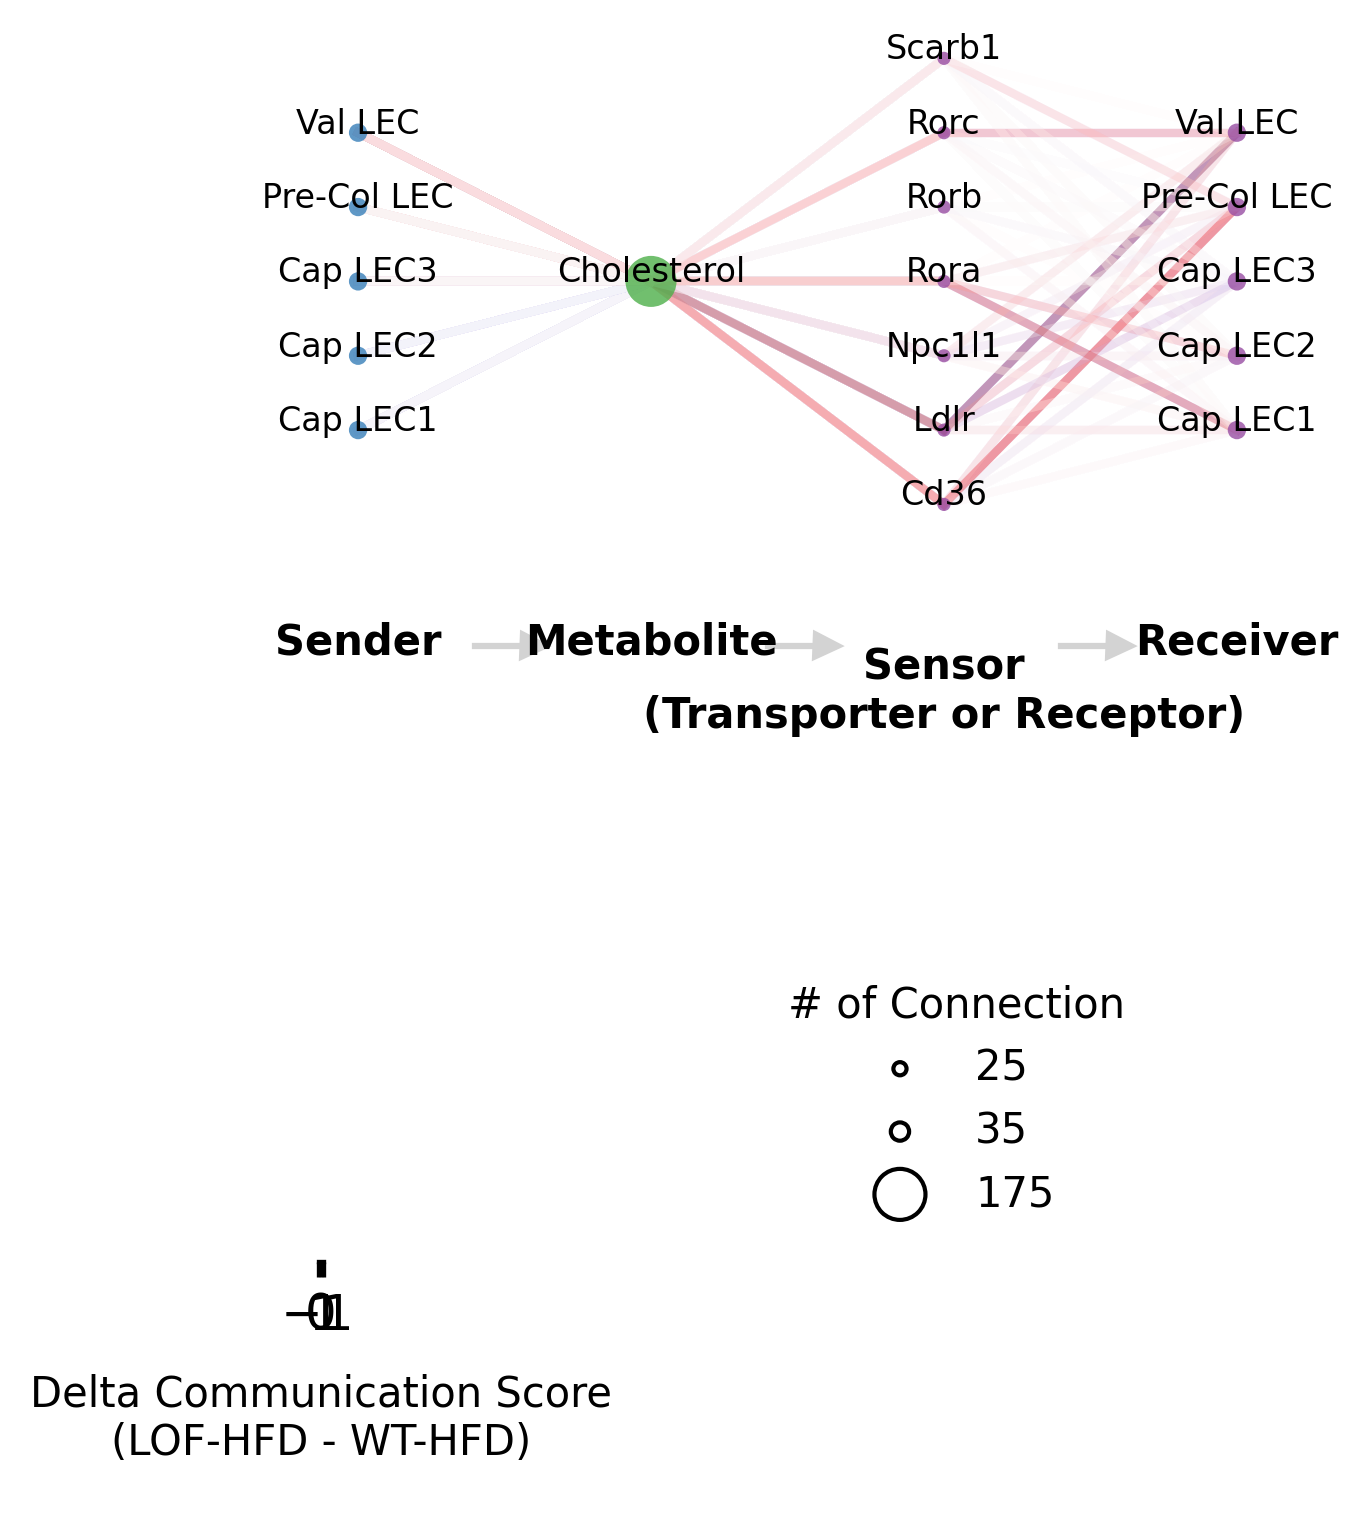

In [14]:
p = _FlowPlot_(comm_res = commu_res_need_mat, 
                pval_method='permutation_test_fdr',
                pval_cutoff=0.05,# 0.05
                metabolite_focus = ["Cholesterol","Cytidine","25-Hydroxycholesterol","27-Hydroxycholesterol"],
                sensor_focus = ['Slc27a5','Scarb1','Rorc','Rorb','Rora','P2ry14','Npc1l1','Ldlr','Cd36'],
                sender_focus = [], #['VSMC','Macrophages'],
                receiver_focus = [],
                remove_unrelevant = True,
                and_or = 'and',
                node_label_size = 8,
                node_alpha = .8,
                figsize = (5,5),
                node_cmap = 'Set1',
                line_cmap = 'seismic', #seismic
                line_vmin = -1,
                line_vmax = 1,
                linewidth_norm = (0.1, 3),
                node_size_norm = (10, 150),
                pdf=None, 
#                 save_plot = "Delta_communication_score_LOF-HFD_WT-HFD_flowplot.pdf", 
                show_plot = True,
                comm_score_col = 'delta',
                comm_score_cutoff =-20,#-20
                cutoff_prop = None,
                text_outline = False,
                return_fig = True)
p.savefig(plotDir+"ALL_cell_TYPES_receiver_cut_off_1_Delta_communication_score_LOF-HFD_WT-HFD_flowplot.pdf")

### 2.5.6 Visualization of the metabolite level or sensor expression in cell groups

In [15]:
met_abudanc_mat=pd.DataFrame(mebo_obj.met_mat.toarray(),
            index = mebo_obj.met_mat_indexer,
            columns = mebo_obj.met_mat_columns)
met_abudanc_mat.to_csv(processedDataDir+'all_metabolite_abudance_matrix.xls',  sep='\t')

[July 23, 2026 15:10:59]: Find genes Index(['Rorc', 'Cd36', 'Scarb1', 'Ldlr', 'Rora', 'Npc1l1', 'Rorb'], dtype='object') to plot violin


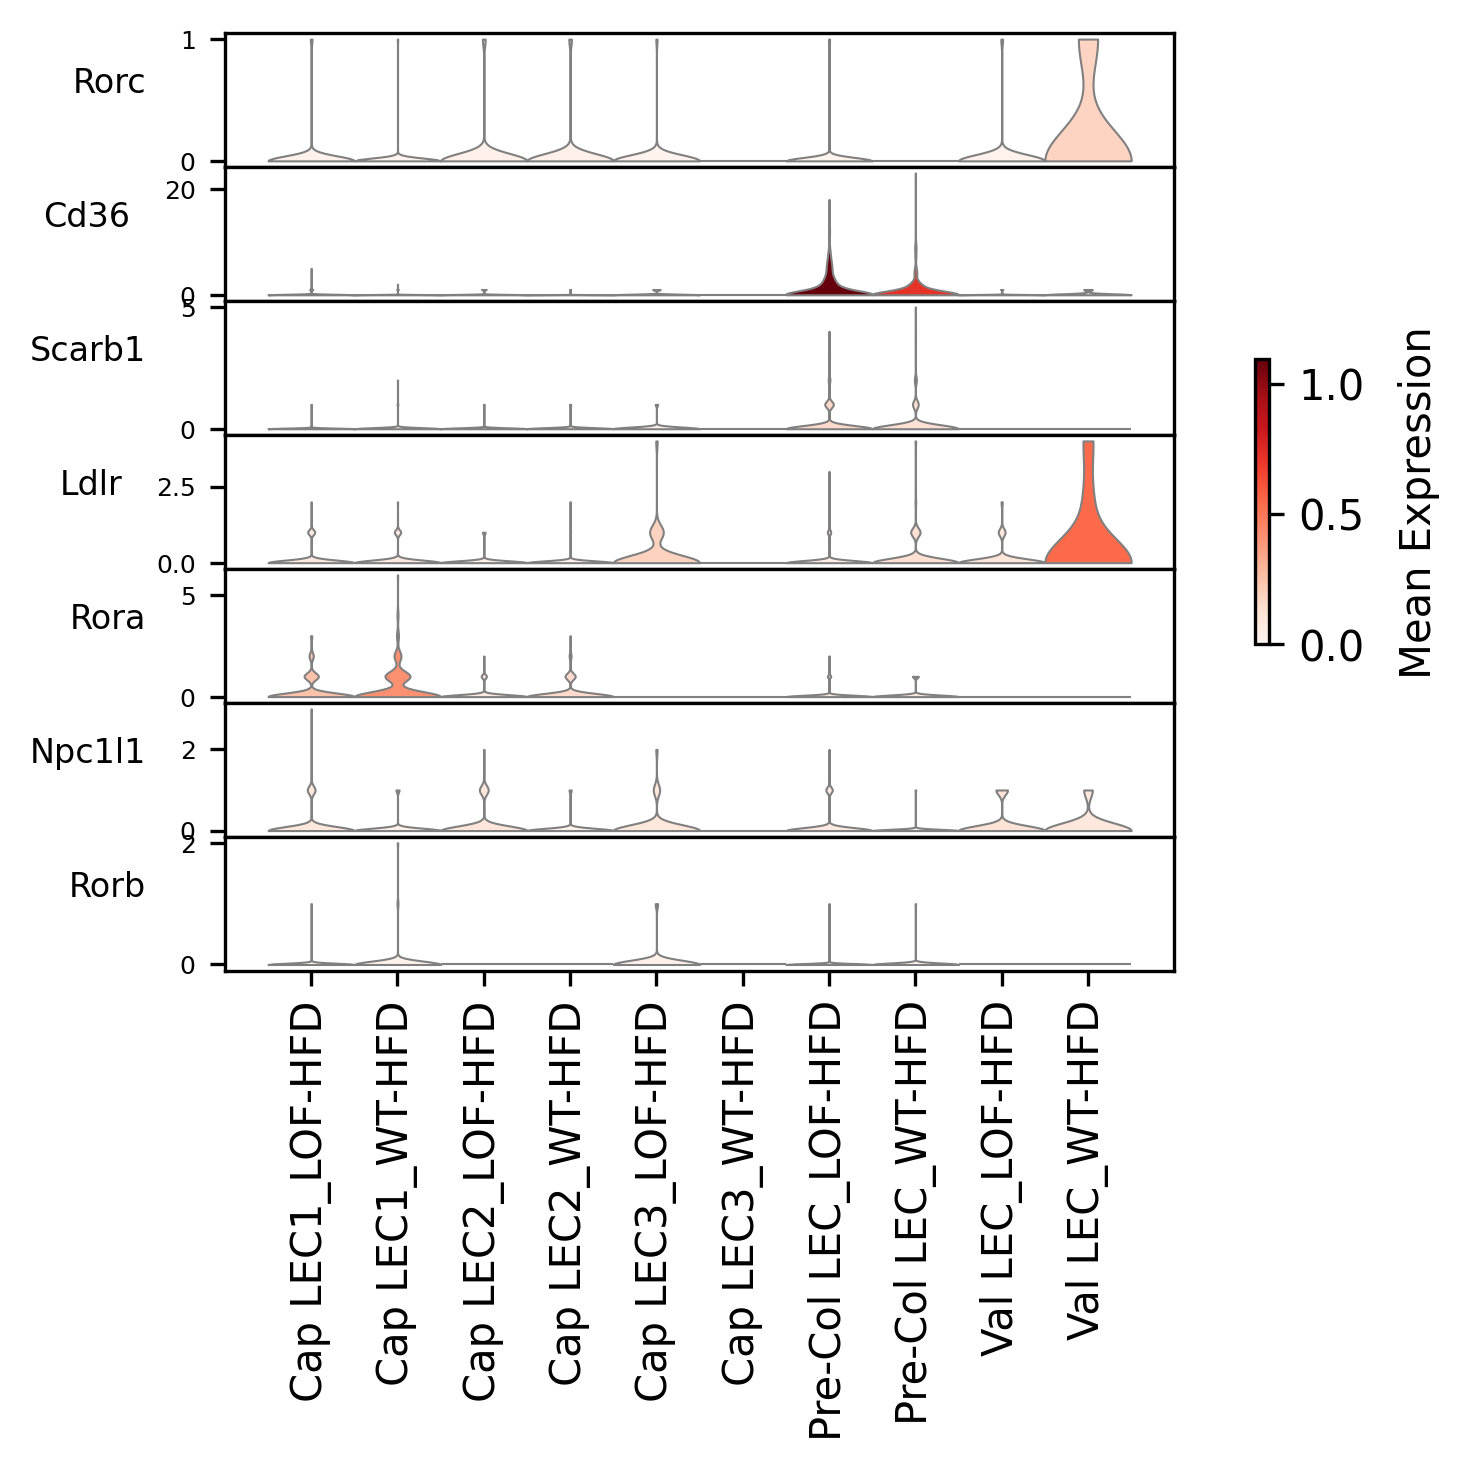

[July 23, 2026 15:11:00]: Find metabolites ['Cholesterol'] to plot violin


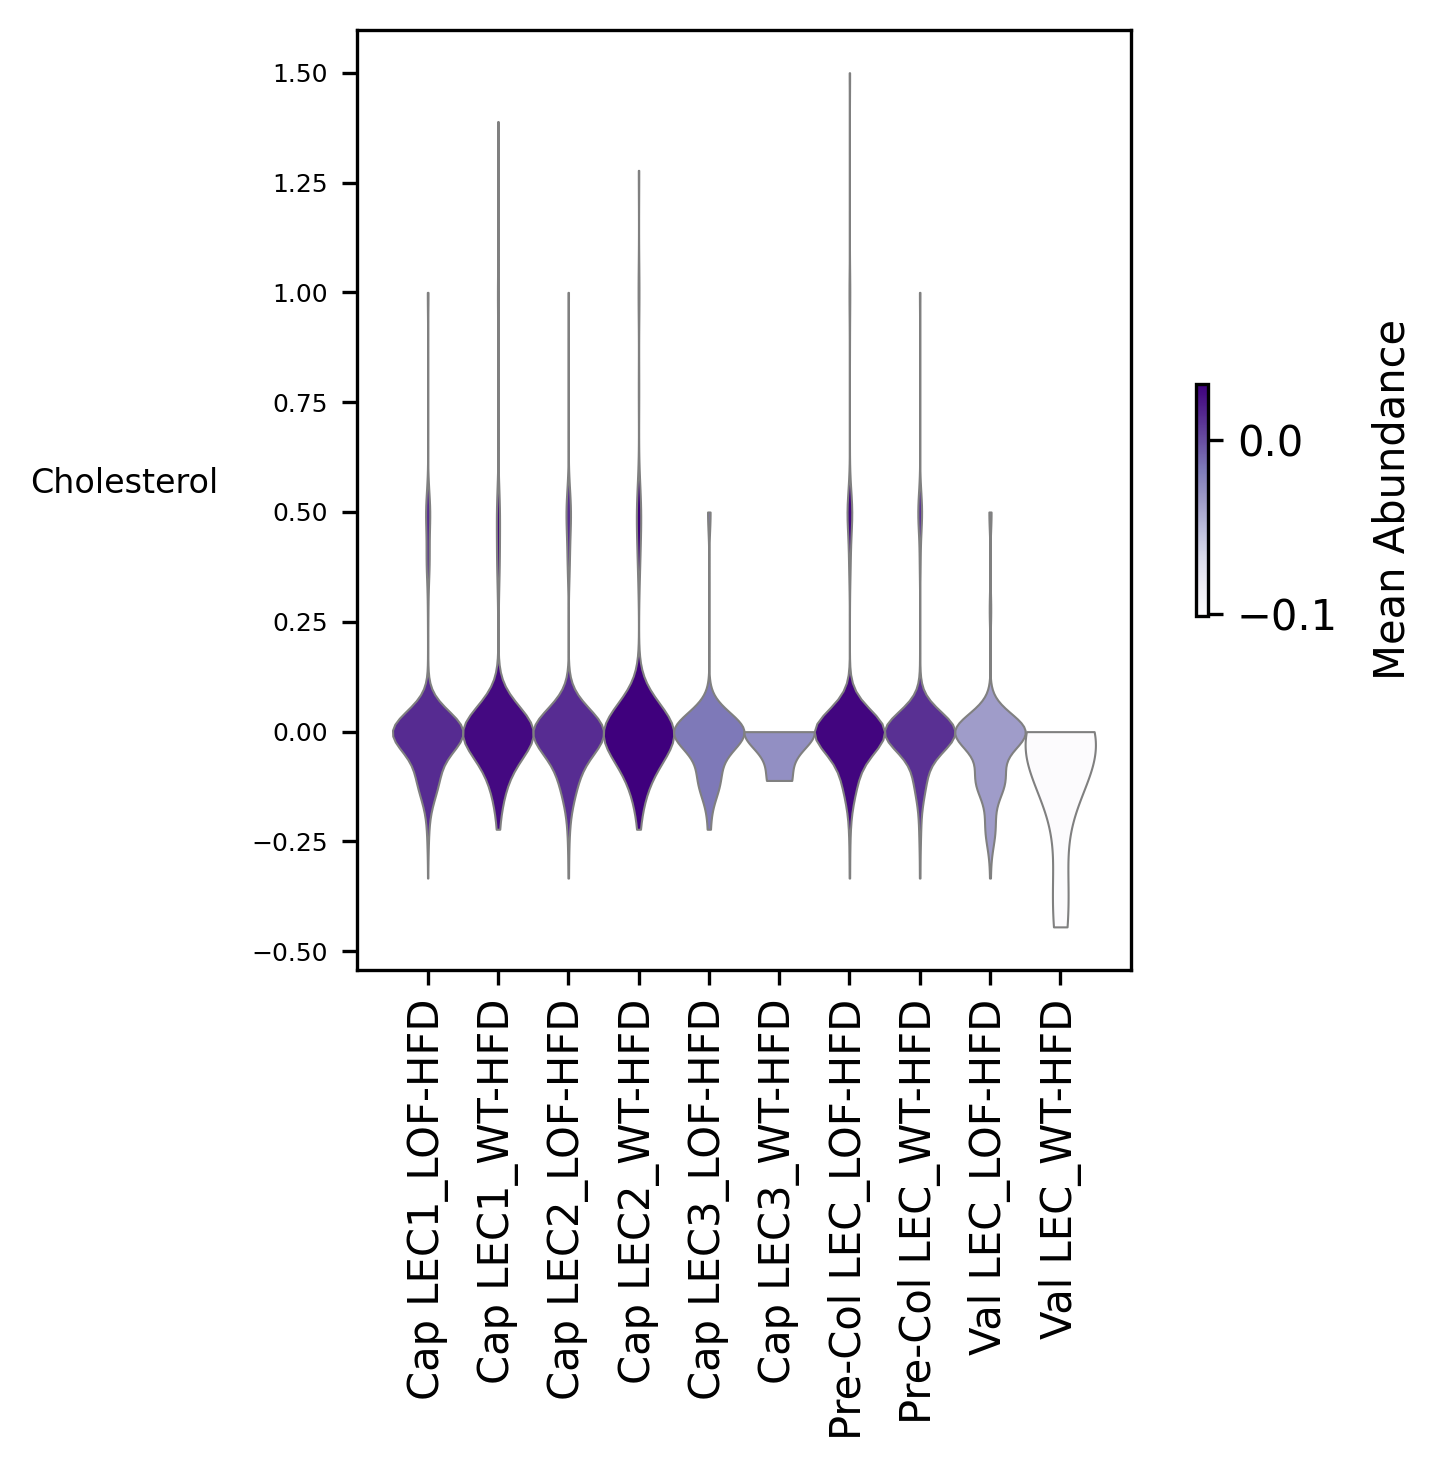

In [16]:
metaSens=metabolites
metaSens.extend(['Scarb1','Rorc','Rorb','Rora','Npc1l1','Ldlr','Cd36'])

## violin plot to show the estimated metabolite abundance of informative metabolties in communication
### here we show five significant metabolites,
### users can pass several metabolites of interest by provide a list
commu_df = mebo_obj.commu_res.copy()
good_sensor = commu_df[(commu_df['permutation_test_fdr']<=0.05)]['Sensor'].unique()
good_met = commu_df[(commu_df['permutation_test_fdr']<=0.05)]['Metabolite_Name'].unique()
mebo_obj.violin_plot(
                    sensor_or_met=["Cholesterol",'Scarb1','Rorc','Rorb','Rora','Npc1l1','Ldlr','Cd36'],# metaSens,
                    #cell_focus= [],
                    cmap=None,
                    vmin=None,
                    vmax=None,
                    #figsize=(10,5),
                    figsize=(5,5),
                    cbar_title='',
                    save=plotDir+"S1p_metabolite_level_in_cell_groups.pdf",
                    show_plot=True
                    )

In [17]:
data=mebo_obj.commu_res
data['Cell_Pair']=[i+"_"+j for i,j in zip(data['Sender'],data['Receiver'])]
data['Cell_Pair']
###########

###########
a=data['permutation_test_fdr'].values
b=a.copy()
for i in range(len(a)):
    if a[i]<.01:
        b[i]=.5
    elif a[i]<.05:
        b[i]=.5
    elif a[i]<.1:
        b[i]=.2
    else:
        b[i]=.2
data['discreatedPvalue']=b
data['pValue']=a
###########
data.to_csv(processedDataDir+'/communicationPvalue.csv')